In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
book_ml = pd.read_csv('../data/book_data_cleaned_forPowerBI.csv')

In [3]:
comment_ml = pd.read_csv('../data/comment_cleaned.csv')

In [4]:
comment_count = comment_ml.groupby('product_id').size().reset_index(name='n_comments')

In [5]:
comment_count.head()


,product_id,n_comments
0,335337,90
1,377644,90
2,378448,90
3,381234,90
4,391045,11


In [6]:
comment_count['n_comments'].value_counts().sort_index()


n_comments
1      67
2      68
3      65
4      56
5      50
     ... 
86     20
87     25
88     49
89     97
90    317
Name: count, Length: 90, dtype: int64

ta gặp vấn đề ở đây khi merge dữ liệu vào để chuẩn bị cho ML, thì vấn đề là khi thu thập dữ liệu bị giới hạn tối đa số comment 90/sách

In [7]:
book_ml = book_ml.merge(comment_count, on='product_id', how='left')
book_ml['n_comments'] = book_ml['n_comments'].fillna(0)

In [8]:
print("✅ Đã merge thành công!")
print(f"Số sách có comment: {(book_ml['n_comments'] > 0).sum()}")
print(f"Số sách không có comment: {(book_ml['n_comments'] == 0).sum()}")
print(f"Số sách có đúng 90 comments: {(book_ml['n_comments'] == 90).sum()}")

✅ Đã merge thành công!
Số sách có comment: 1634
Số sách không có comment: 96
Số sách có đúng 90 comments: 295


# Linear Regression

## Dự đoán doanh thu sách

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [10]:
features = [
    'current_price',
    'n_review',         # YẾU TỐ QUAN TRỌNG NHẤT
    'n_comments',       # Thêm số lượng comment (bị giới hạn tối đa 90)
    'pages',
    'avg_rating',
    'discount'
]
target = 'revenue'  # Cột doanh thu

X = book_ml[features]
y = book_ml[target]

In [11]:
# Chia dữ liệu train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Kích thước tập train: {X_train.shape}")
print(f"Kích thước tập test: {X_test.shape}")

Kích thước tập train: (1384, 6)
Kích thước tập test: (346, 6)


In [12]:
# Tạo và huấn luyện mô hình Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

print("Mô hình đã được huấn luyện thành công!")
print(f"\nHệ số (Coefficients): {model.coef_}")
print(f"Hệ số chặn (Intercept): {model.intercept_}")

Mô hình đã được huấn luyện thành công!

Hệ số (Coefficients): [ 2325.57983735    26.5235799     82.09622331    -6.42323003
   867.59703098 -6328.97114054]
Hệ số chặn (Intercept): -11023.183101031012


In [13]:
# Dự đoán
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Đánh giá mô hình
print("=== Kết quả trên tập TRAIN ===")
print(f"R² Score: {r2_score(y_train, y_train_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred):.2f}")
print(f"MSE: {mean_squared_error(y_train, y_train_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f}")

print("\n=== Kết quả trên tập TEST ===")
print(f"R² Score: {r2_score(y_test, y_test_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_test_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")

=== Kết quả trên tập TRAIN ===
R² Score: 0.0826
MAE: 10003.42
MSE: 5893246338.09
RMSE: 76767.48

=== Kết quả trên tập TEST ===
R² Score: 0.6165
MAE: 8357.61
MSE: 286119006.80
RMSE: 16915.05


chỉ số đánh giá cho thấy mô hình Linear Regression có hiệu năng thấp và không ổn định, đặc biệt với các sản phẩm có doanh thu cao và chưa đáp ứng tốt yêu cầu dự đoán doanh thu.

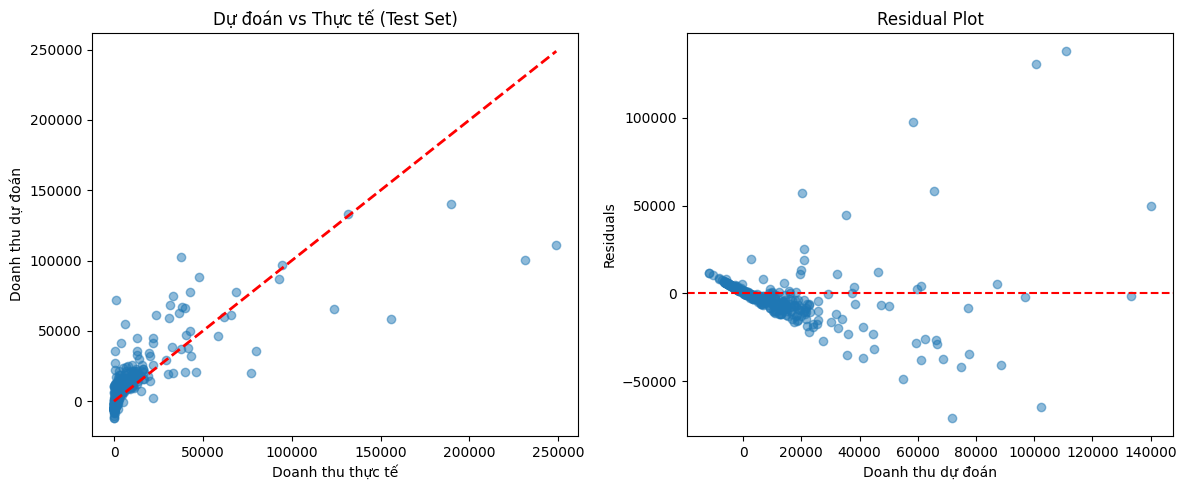

In [14]:
# Visualization - So sánh giá trị thực và dự đoán
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Doanh thu thực tế')
plt.ylabel('Doanh thu dự đoán')
plt.title('Dự đoán vs Thực tế (Test Set)')

plt.subplot(1, 2, 2)
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Doanh thu dự đoán')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.tight_layout()
plt.show()

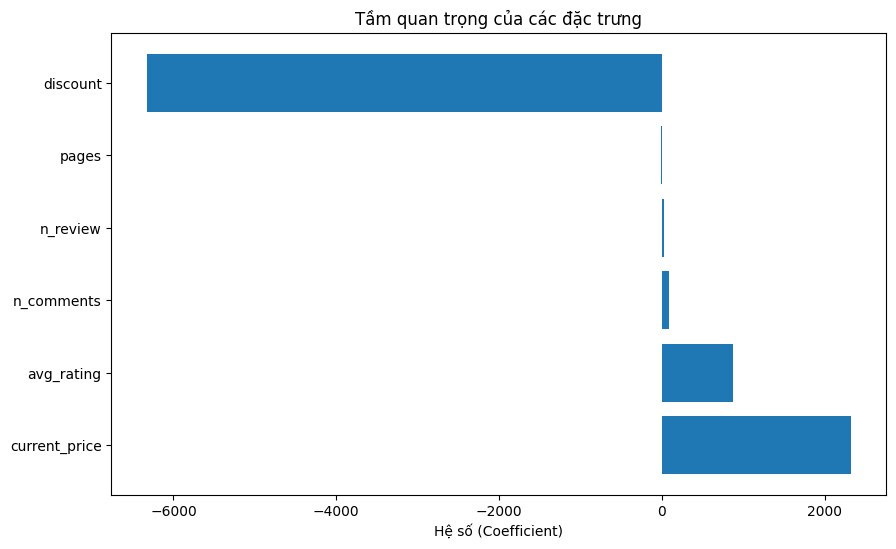

         Feature  Coefficient
0  current_price  2325.579837
4     avg_rating   867.597031
2     n_comments    82.096223
1       n_review    26.523580
3          pages    -6.423230
5       discount -6328.971141


In [15]:
# Hiển thị tầm quan trọng của features
feature_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])
plt.xlabel('Hệ số (Coefficient)')
plt.title('Tầm quan trọng của các đặc trưng')
plt.show()

print(feature_importance)

## Kết luận
tôi thấy mô hình Linear Regression này không phù hợp với dataset này, vì ở dataset này có nhiều sách doanh thu thấp, ít sách doanh thu cao từ đó tao ra Outlier nhưng Outlier ở đây biểu hiện cho giá trị hợp lệ không phải lỗi

# Random Forest Regressor

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [17]:
rf_model = RandomForestRegressor(
    n_estimators=300,      # số cây
    max_depth=None,        # để cây tự học
    min_samples_split=5,   # tránh overfit
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("✅ Random Forest đã được huấn luyện!")


✅ Random Forest đã được huấn luyện!


In [18]:
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf  = rf_model.predict(X_test)


In [19]:
print("=== Random Forest – TRAIN ===")
print(f"R² Score: {r2_score(y_train, y_train_pred_rf):.4f}")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred_rf):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_rf)):.2f}")

print("\n=== Random Forest – TEST ===")
print(f"R² Score: {r2_score(y_test, y_test_pred_rf):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred_rf):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_rf)):.2f}")


=== Random Forest – TRAIN ===
R² Score: 0.4932
MAE: 4622.95
RMSE: 57056.62

=== Random Forest – TEST ===
R² Score: 0.7582
MAE: 3898.99
RMSE: 13430.22


tạm ổn, còn thiếu phần biểu đồ cây sẽ thêm vào sau 

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# 1. Log-transform target
y_log = np.log1p(book_ml['revenue'])

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# 3. Train Random Forest
rf_log = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf_log.fit(X_train, y_train)

# 4. Predict (log-scale)
y_train_pred_log = rf_log.predict(X_train)
y_test_pred_log  = rf_log.predict(X_test)

# 5. Đánh giá (log scale)
print("=== RF + log(revenue) – TRAIN (log-scale) ===")
print("R²:", r2_score(y_train, y_train_pred_log))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred_log)))

print("\n=== RF + log(revenue) – TEST (log-scale) ===")
print("R²:", r2_score(y_test, y_test_pred_log))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred_log)))

# (Optional) Quay về doanh thu gốc để so MAE/RMSE thực tế
y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred_log)

print("\n=== TEST – quay về doanh thu gốc ===")
print("MAE:", mean_absolute_error(y_test_real, y_test_pred_real))
print("RMSE:", np.sqrt(mean_squared_error(y_test_real, y_test_pred_real)))


=== RF + log(revenue) – TRAIN (log-scale) ===
R²: 0.9912415029187593
RMSE: 0.1907935411834357

=== RF + log(revenue) – TEST (log-scale) ===
R²: 0.9356446798449829
RMSE: 0.5254469475981866

=== TEST – quay về doanh thu gốc ===
MAE: 3804.151778436013
RMSE: 13881.18112628011


sau khi thử với log thì ổn hơn, ta có thể kết luận sơ bộ trước mắt là Randome Forest + Log là ổn nhất

### So sánh giữa hai mô hình Random Forst và Random Forest Log

         feature  importance
1       n_review    0.858789
0  current_price    0.084522
2     n_comments    0.023675
3          pages    0.011794
5       discount    0.010638
4     avg_rating    0.010582


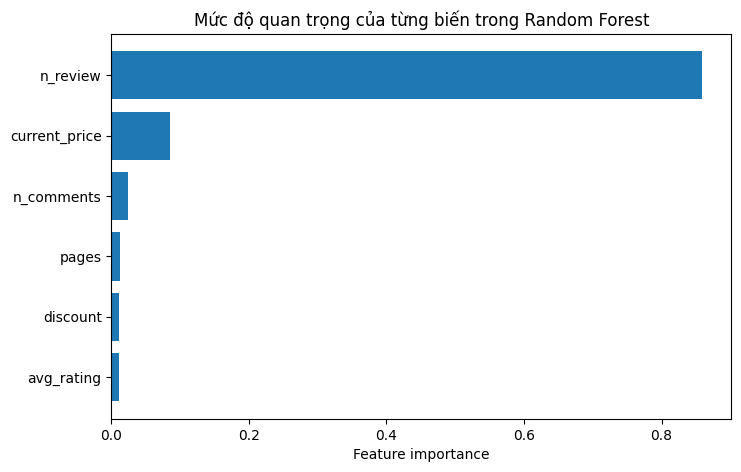

In [21]:
# 1. Tính độ quan trọng
fi = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_log.feature_importances_
}).sort_values('importance', ascending=False)

print(fi)

# 2. Vẽ biểu đồ
plt.figure(figsize=(8, 5))
plt.barh(fi['feature'], fi['importance'])
plt.gca().invert_yaxis()   # cho biến quan trọng nhất lên trên
plt.xlabel("Feature importance")
plt.title("Mức độ quan trọng của từng biến trong Random Forest")
plt.show()

**n_review chiếm 85.8%** mức độ quan trọng trong mô hình Random Forest. Điều này phù hợp với hành vi mua hàng của người dùng: sản phẩm càng nhiều đánh giá thì càng thu hút và tạo niềm tin, từ đó thúc đẩy doanh số.

**Kết luận** doanh thu bị chi phối chủ yếu bởi mức độ phổ biến của sách

- Mặc dù n_review và n_comments có mức độ quan trọng cao trong mô hình, nhưng đây là những biến thể hiện mức độ phổ biến và không phảu yếu tố doanh nghiệp có thể điều chỉnh trực tiếp được. Vì vậy ta sẽ tập trung phân tích PDP, phân tích vào các biến có thể hành động như Discount và Current_Price để đưa ra Insight thực tế hơn.


### Biểu đồ PDP

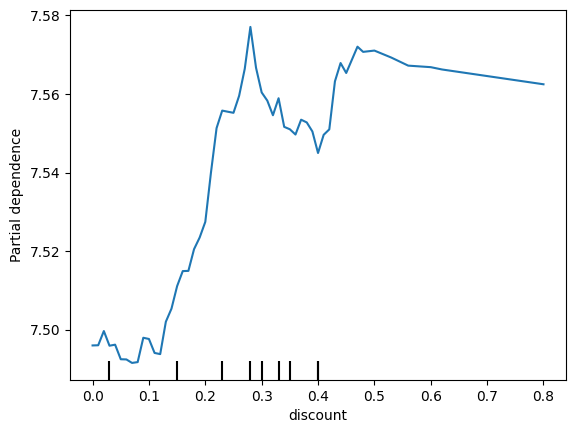

In [22]:
from sklearn.inspection import PartialDependenceDisplay
PartialDependenceDisplay.from_estimator(rf_log, X_train, ['discount'])

- Mặc dù biến discount trong Feature Important không cao nhưng vẫn có ý nghĩa lớn về mặt kinh doanh vì đây là thứ có thể điều chỉnh trực tiếp

doanh thu tăng từ 0.15 -> 0.3 tương đương từ 15% đến 30%, đây là vùng discount hiệu quả nhất để áp dụng vào sản phẩm

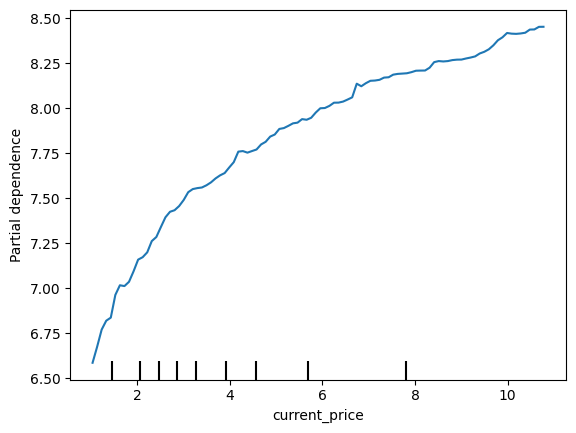

In [26]:
PartialDependenceDisplay.from_estimator(
    rf_log, X_train, ['current_price']
)


- PDP cho biến current_price cho thấy mối quan hệ tăng dần giữa giá bán và doanh thu nghe có vẻ hơi ngược đời nhưng đây là sự thật
- Giá cao thường đi kèm với các đầu sách có nội dung chuyên sâu hoặc độ phổ biến cao nên doanh thu trung bình cũng cao hơn.

**Kết luận** 
- Tăng giá không làm giảm doanh thu đáng kể đối với nhóm sách đang bán tốt.
- Có thể xem xét tăng giá nhẹ đối với các đầu sách hot mà không sợ mất doanh thu.

### Dự đoán doanh thu dựa vào Discount

In [50]:
def simulate_discount_for_testset(discounts=[0, 0.1, 0.2, 0.3, 0.4, 0.5]):
    """
    Mô phỏng discount trên TOÀN BỘ test set 
    """
    results = []
    
    for d in discounts:
        X_test_sim = X_test.copy()
        X_test_sim['discount'] = d
        
        # Predict log -> revenue
        y_log_pred = rf_log.predict(X_test_sim)
        revenue_pred = np.expm1(y_log_pred)
        
        avg_revenue = revenue_pred.mean()
        
        results.append({
            'discount': f"{d*100:.0f}%",
            'avg predicted revenue': f"{avg_revenue:,.0f} VND",
            'total revenue': f"{revenue_pred.sum():,.0f} VND"
        })
    
    return pd.DataFrame(results)

# Chạy thử
simulate_discount_for_testset()

,discount,avg predicted revenue,total revenue
0,0%,"8,989 VND","3,110,096 VND"
1,10%,"9,039 VND","3,127,514 VND"
2,20%,"9,264 VND","3,205,203 VND"
3,30%,"8,843 VND","3,059,762 VND"
4,40%,"8,580 VND","2,968,650 VND"
5,50%,"8,461 VND","2,927,674 VND"


Discount thấp không có ảnh hưởng rõ rệt, discount vừa phải (đặc biệt là mức 20%) mang lại doanh thu tối ưu, trong khi discount cao (30–50%) dẫn đến giảm doanh thu.

**Kết luận**
- Nên tập trung triển khai giảm giá ở mức 15%-25%
- Discount nhẹ (<10%) không hiệu quả, còn discount sâu (>30%) làm giảm doanh thu.

# XGBoost

In [23]:
from xgboost import XGBRegressor


Kích thước tập train: (1384, 6)
Kích thước tập test : (346, 6)

Mô hình XGBoost đã được huấn luyện xong!

=== XGBoost Regressor – TRAIN ===
R²   : 0.9997
MAE  : 806.12
RMSE : 1,380.65

=== XGBoost Regressor – TEST ===
R²   : -3.3935
MAE  : 9,385.58
RMSE : 57,252.00


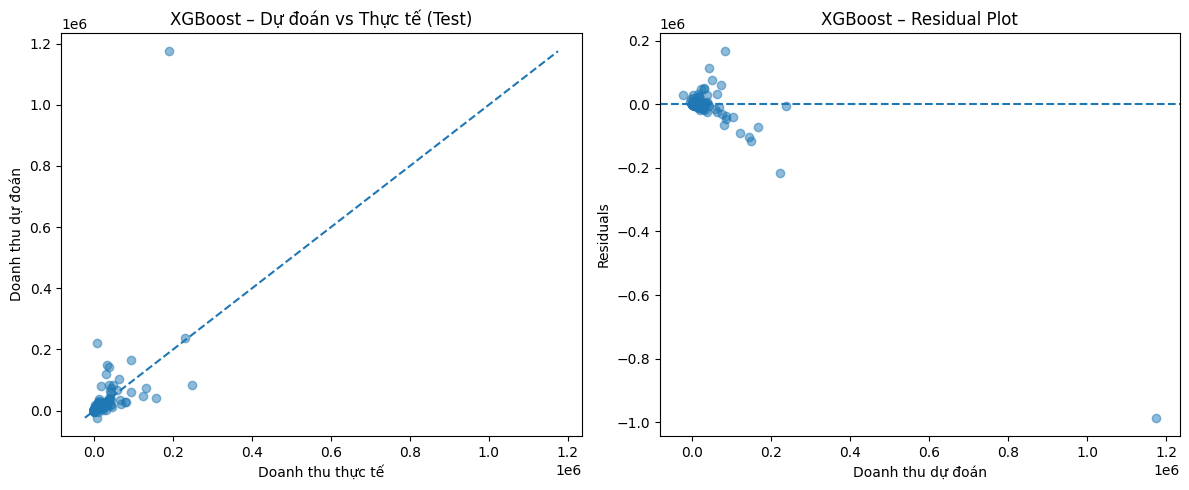

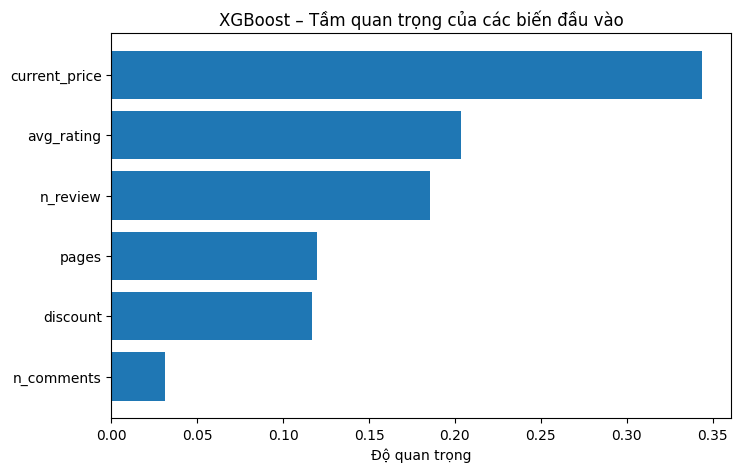


Tầm quan trọng của feature:
         Feature  Importance
0  current_price    0.343848
4     avg_rating    0.203731
1       n_review    0.185205
3          pages    0.119440
5       discount    0.116809
2     n_comments    0.030967


In [24]:
# ====== 1. Import thư viện ======
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor

# ====== 2. Chọn features & target ======
features = [
    'current_price',
    'n_review',     # số lượng review
    'n_comments',   # số comment (đã giới hạn <= 90)
    'pages',
    'avg_rating',
    'discount'
]
target = 'revenue'

X = book_ml[features]
y = book_ml[target]

# (Nếu có NaN thì nên xử lý, ví dụ fill 0)
# X = X.fillna(0)

# ====== 3. Chia train / test ======
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Kích thước tập train:", X_train.shape)
print("Kích thước tập test :", X_test.shape)

# ====== 4. Khởi tạo & train mô hình XGBoost Regressor ======
xgb_model = XGBRegressor(
    n_estimators=300,       # số cây
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'   # regression
)

xgb_model.fit(X_train, y_train)
print("\nMô hình XGBoost đã được huấn luyện xong!")

# ====== 5. Dự đoán ======
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb  = xgb_model.predict(X_test)

# ====== 6. Đánh giá mô hình ======
def print_regression_report(name, y_true_train, y_pred_train, y_true_test, y_pred_test):
    print(f"\n=== {name} – TRAIN ===")
    r2_train  = r2_score(y_true_train, y_pred_train)
    mae_train = mean_absolute_error(y_true_train, y_pred_train)
    rmse_train = np.sqrt(mean_squared_error(y_true_train, y_pred_train))
    print(f"R²   : {r2_train:.4f}")
    print(f"MAE  : {mae_train:,.2f}")
    print(f"RMSE : {rmse_train:,.2f}")

    print(f"\n=== {name} – TEST ===")
    r2_test  = r2_score(y_true_test, y_pred_test)
    mae_test = mean_absolute_error(y_true_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
    print(f"R²   : {r2_test:.4f}")
    print(f"MAE  : {mae_test:,.2f}")
    print(f"RMSE : {rmse_test:,.2f}")

print_regression_report(
    "XGBoost Regressor",
    y_train, y_train_pred_xgb,
    y_test,  y_test_pred_xgb
)

# ====== 7. Vẽ biểu đồ Dự đoán vs Thực tế (Test set) ======
plt.figure(figsize=(12, 5))

# Scatter: y thực vs y dự đoán
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred_xgb, alpha=0.5)
min_val = min(y_test.min(), y_test_pred_xgb.min())
max_val = max(y_test.max(), y_test_pred_xgb.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')
plt.xlabel('Doanh thu thực tế')
plt.ylabel('Doanh thu dự đoán')
plt.title('XGBoost – Dự đoán vs Thực tế (Test)')

# Residual plot
plt.subplot(1, 2, 2)
residuals = y_test - y_test_pred_xgb
plt.scatter(y_test_pred_xgb, residuals, alpha=0.5)
plt.axhline(y=0, linestyle='--')
plt.xlabel('Doanh thu dự đoán')
plt.ylabel('Residuals')
plt.title('XGBoost – Residual Plot')

plt.tight_layout()
plt.show()

# ====== 8. Tầm quan trọng của features (Feature importance) ======
importance = xgb_model.feature_importances_
fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(fi_df['Feature'], fi_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Độ quan trọng')
plt.title('XGBoost – Tầm quan trọng của các biến đầu vào')
plt.show()

print("\nTầm quan trọng của feature:")
print(fi_df)


cái này cũng đéo ổn